## PQK-SVM WIG20 BANKI - wersja 17.09.2026 - 1. Dynamiczny Tuning Hiperparametrów

>>> Załadowano dane: 615 tygodni. Rozpoczęcie potoku z RandomizedSearchCV...


Progress in queue:   0%|          | 0/1 [01:21<?, ?it/s]



>>> Start Walk-Forward OOS (Rozmiar okna: 104 tyg, Split: 5)
  Zakończono: Tydzień 104/615 | Najlepsze SVM params (QPU): {'svm__gamma': 0.01, 'svm__class_weight': 'balanced', 'svm__C': 1.0}
  Zakończono: Tydzień 156/615 | Najlepsze SVM params (QPU): {'svm__gamma': 1.0, 'svm__class_weight': None, 'svm__C': 5.0}
  Zakończono: Tydzień 208/615 | Najlepsze SVM params (QPU): {'svm__gamma': 0.01, 'svm__class_weight': None, 'svm__C': 1.0}
  Zakończono: Tydzień 260/615 | Najlepsze SVM params (QPU): {'svm__gamma': 0.01, 'svm__class_weight': None, 'svm__C': 1.0}
  Zakończono: Tydzień 312/615 | Najlepsze SVM params (QPU): {'svm__gamma': 0.01, 'svm__class_weight': None, 'svm__C': 10.0}
  Zakończono: Tydzień 364/615 | Najlepsze SVM params (QPU): {'svm__gamma': 0.01, 'svm__class_weight': None, 'svm__C': 10.0}
  Zakończono: Tydzień 416/615 | Najlepsze SVM params (QPU): {'svm__gamma': 1.0, 'svm__class_weight': None, 'svm__C': 5.0}
  Zakończono: Tydzień 468/615 | Najlepsze SVM params (QPU): {'svm__gamm

,Accuracy,F1-Score,AUC ROC
Logistic Reg,0.4540,0.4431,0.4628
Classical SVM,0.5029,0.5753,0.4859
PQK Ideal Sim,0.5108,0.5928,0.4767
PQK Real QPU,0.5068,0.5909,0.4891


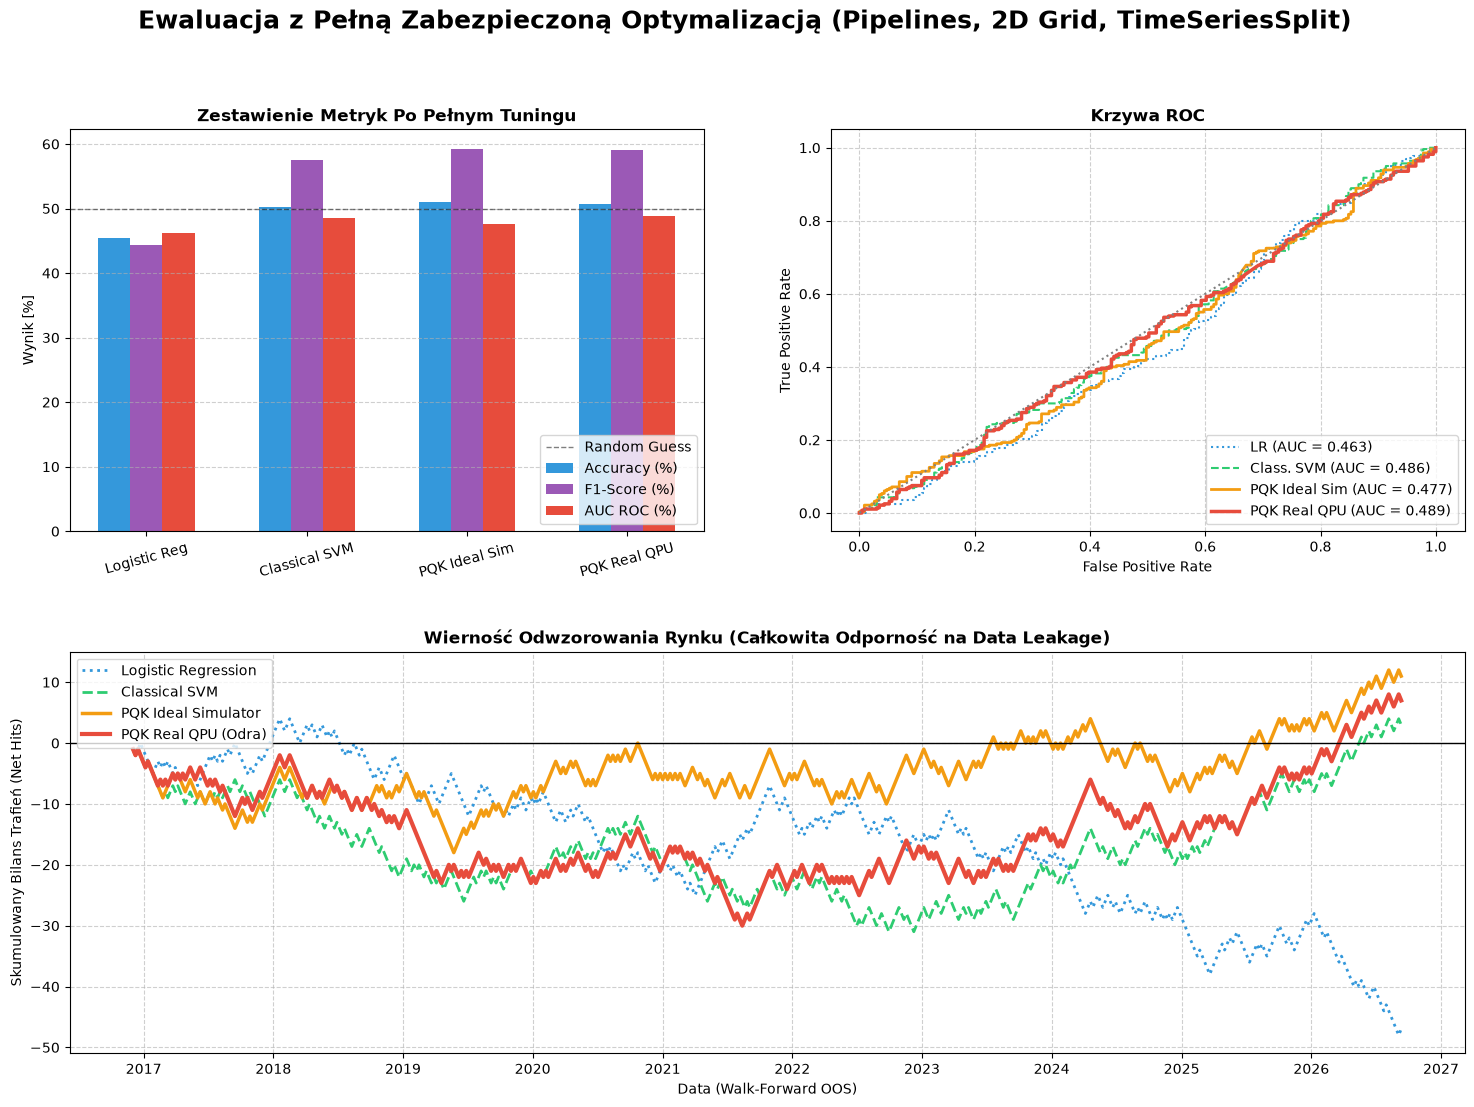

In [6]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from iqm.qiskit_iqm import IQMProvider

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I DANE SUROWE
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"
file_real_qpu = "phi_real_odra.npy"
file_sim_ideal = "phi_sim_ideal.npy"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         
    'pbv_peo', 'rentownosc_10y',   
    'pbv_san', 'eurpln',           
    'pbv_ing', 'wig20',            
    'pbv_mbk', 'zmiennosc'         
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)

X_raw = df[FEATURES_MAP].values
y = df["target_y"].values
dates = df.index.values

# Globalne skalowanie kątowe TYLKO na potrzeby generacji/wczytania bramek kwantowych
# (Ponowne odpytywanie QPU w każdej pętli CV zajęłoby miesiące)
X_quantum = MinMaxScaler(feature_range=(0, 2 * np.pi)).fit_transform(X_raw)

print(f">>> Załadowano dane: {len(y)} tygodni. Rozpoczęcie potoku z RandomizedSearchCV...")

# ==========================================
# 2 & 3. GENERATOR I WCZYTYWANIE CACHE (QPU / SYMULATOR)
# ==========================================
def build_base_ansatz(x, num_qubits=5):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)
    qc.cx(num_qubits - 1, 0)
    return qc

def get_ideal_projections(X_norm, filepath, num_qubits=5):
    if os.path.exists(filepath): return np.load(filepath)
    estimator = StatevectorEstimator()
    observables = [SparsePauliOp("".join(['I'] * (num_qubits - 1 - q) + [pauli] + ['I'] * q)) for q in range(num_qubits) for pauli in ['X', 'Y', 'Z']]
    Phi_sim = [[float(res.data.evs) for res in estimator.run([(build_base_ansatz(x, num_qubits), obs) for obs in observables]).result()] for x in X_norm]
    np.save(filepath, np.array(Phi_sim))
    return np.array(Phi_sim)

def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_real_qpu_projections(X_norm, filepath, num_qubits=5, shots=4000, batch_size=50):
    if os.path.exists(filepath): return np.load(filepath)
    env_paths = ["../iqm_token.env", "iqm_token.env", "token.env", "../token.env"]
    for path in env_paths:
        if os.path.exists(path):
            load_dotenv(path)
            break
    provider = IQMProvider(os.getenv("SERVER"))
    backend = provider.get_backend()
    
    all_circuits = []
    for x in X_norm:
        qc_x = build_base_ansatz(x, num_qubits)
        for i in range(num_qubits): qc_x.h(i)
        qc_x.measure_all()
        
        qc_y = build_base_ansatz(x, num_qubits)
        for i in range(num_qubits): 
            qc_y.sdg(i)
            qc_y.h(i)
        qc_y.measure_all()
        
        qc_z = build_base_ansatz(x, num_qubits)
        qc_z.measure_all()
        all_circuits.extend([qc_x, qc_y, qc_z])

    transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
    all_counts = []
    for i in range(0, len(transpiled), batch_size):
        job = backend.run(transpiled[i : i + batch_size], shots=shots)
        for j in range(len(transpiled[i : i + batch_size])): all_counts.append(job.result().get_counts(j))
            
    Phi_odra = np.zeros((len(X_norm), num_qubits * 3))
    for i in range(len(X_norm)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    np.save(filepath, Phi_odra)
    return Phi_odra

# Wczytanie/Wygenerowanie Rzutów
Phi_sim = get_ideal_projections(X_quantum, file_sim_ideal)
Phi_real = get_real_qpu_projections(X_quantum, file_real_qpu)

# ==========================================
# 4. ZAAWANSOWANY TUNING: PIPELINES I PARAMETRY
# ==========================================
TRAIN_WINDOW = 104  # Zwiększono okno do 2 lat dla rzetelności CV
n_samples = len(y)

# Definicje Potoków (Pipelines) - Zabezpieczenie przed Data Leakage
pipe_lr = Pipeline([('scaler', MinMaxScaler()), ('lr', LogisticRegression(max_iter=1000))])
pipe_rbf = Pipeline([('scaler', MinMaxScaler()), ('svm', SVC(kernel="rbf", probability=True))])

# Modele kwantowe działają bezpośrednio na macierzach rzutów, standaryzujemy je wewnętrznie
pipe_qpu = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel="rbf", probability=True))])

# Dwuwymiarowa siatka parametrów + Balansowanie Klas
param_dist_lr = {
    'lr__C': [0.1, 1.0, 5.0, 10.0, 50.0],
    'lr__class_weight': [None, 'balanced']
}
param_dist_svm = {
    'svm__C': [0.1, 1.0, 5.0, 10.0, 50.0],
    'svm__gamma': ['scale', 0.01, 0.1, 1.0],
    'svm__class_weight': [None, 'balanced']
}

# Walidacja krzyżowa oparta na szeregach czasowych
tscv = TimeSeriesSplit(n_splits=5)

results = {"y_true": [], "dates": [], "p_lr": [], "p_rbf": [], "p_sim": [], "p_real": []}

print(f"\n>>> Start Walk-Forward OOS (Rozmiar okna: {TRAIN_WINDOW} tyg, Split: 5)")

# Używamy mniejszej liczby iteracji (n_iter=15) by przyspieszyć działanie przy 4 modelach
for t in range(TRAIN_WINDOW, n_samples):
    # Podział na zbiór treningowy i 1 okres testowy (OOS)
    X_tr, X_te = X_raw[t - TRAIN_WINDOW : t], X_raw[t : t + 1]
    P_sim_tr, P_sim_te = Phi_sim[t - TRAIN_WINDOW : t], Phi_sim[t : t + 1]
    P_real_tr, P_real_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # 1. Regresja Logistyczna (RandomizedSearchCV + Pipeline)
    rs_lr = RandomizedSearchCV(pipe_lr, param_dist_lr, n_iter=8, cv=tscv, scoring='roc_auc', n_jobs=-1, random_state=42)
    rs_lr.fit(X_tr, y_tr)
    results["p_lr"].append(rs_lr.predict_proba(X_te)[0, 1])
    
    # 2. Klasyczny SVM (2D Tuning + Pipeline)
    rs_rbf = RandomizedSearchCV(pipe_rbf, param_dist_svm, n_iter=15, cv=tscv, scoring='roc_auc', n_jobs=-1, random_state=42)
    rs_rbf.fit(X_tr, y_tr)
    results["p_rbf"].append(rs_rbf.predict_proba(X_te)[0, 1])
    
    # 3. Model Kwantowy - Symulator Idealny
    rs_sim = RandomizedSearchCV(pipe_qpu, param_dist_svm, n_iter=15, cv=tscv, scoring='roc_auc', n_jobs=-1, random_state=42)
    rs_sim.fit(P_sim_tr, y_tr)
    results["p_sim"].append(rs_sim.predict_proba(P_sim_te)[0, 1])

    # 4. Model Kwantowy - Prawdziwe QPU Odra
    rs_real = RandomizedSearchCV(pipe_qpu, param_dist_svm, n_iter=15, cv=tscv, scoring='roc_auc', n_jobs=-1, random_state=42)
    rs_real.fit(P_real_tr, y_tr)
    results["p_real"].append(rs_real.predict_proba(P_real_te)[0, 1])
    
    if (t % 52) == 0:
        print(f"  Zakończono: Tydzień {t}/{n_samples} | Najlepsze SVM params (QPU): {rs_real.best_params_}")

# ==========================================
# 5. DASHBOARD I METRYKI KOŃCOWE
# ==========================================
for k in results: results[k] = np.array(results[k])
y_pred_lr = (results["p_lr"] > 0.5).astype(int)
y_pred_rbf = (results["p_rbf"] > 0.5).astype(int)
y_pred_sim = (results["p_sim"] > 0.5).astype(int)
y_pred_real = (results["p_real"] > 0.5).astype(int)

metrics = {
    "Logistic Reg": [accuracy_score(results["y_true"], y_pred_lr), f1_score(results["y_true"], y_pred_lr), roc_auc_score(results["y_true"], results["p_lr"])],
    "Classical SVM": [accuracy_score(results["y_true"], y_pred_rbf), f1_score(results["y_true"], y_pred_rbf), roc_auc_score(results["y_true"], results["p_rbf"])],
    "PQK Ideal Sim": [accuracy_score(results["y_true"], y_pred_sim), f1_score(results["y_true"], y_pred_sim), roc_auc_score(results["y_true"], results["p_sim"])],
    "PQK Real QPU": [accuracy_score(results["y_true"], y_pred_real), f1_score(results["y_true"], y_pred_real), roc_auc_score(results["y_true"], results["p_real"])]
}

df_metrics = pd.DataFrame(metrics, index=["Accuracy", "F1-Score", "AUC ROC"]).T
print("\n--- OSTATECZNE WYNIKI BADAWCZE (Bayesian-Style Tuning & Pipelines) ---")
display(df_metrics.style.format("{:.4f}"))

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Ewaluacja z Pełną Zabezpieczoną Optymalizacją (Pipelines, 2D Grid, TimeSeriesSplit)", fontsize=18, fontweight='bold', y=0.98)
grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

ax1 = fig.add_subplot(grid[0, 0])
x = np.arange(len(df_metrics))
width = 0.2
ax1.bar(x - 1.5*width, df_metrics["Accuracy"] * 100, width, label='Accuracy (%)', color='#3498db')
ax1.bar(x - 0.5*width, df_metrics["F1-Score"] * 100, width, label='F1-Score (%)', color='#9b59b6')
ax1.bar(x + 0.5*width, df_metrics["AUC ROC"] * 100, width, label='AUC ROC (%)', color='#e74c3c')
ax1.set_xticks(x - 0.5*width)
ax1.set_xticklabels(df_metrics.index, fontsize=10, rotation=15)
ax1.axhline(50.0, color="black", ls="--", lw=1, alpha=0.5, label="Random Guess")
ax1.set_ylabel("Wynik [%]")
ax1.set_title("Zestawienie Metryk Po Pełnym Tuningu", fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(axis='y', linestyle='--', alpha=0.6)

ax2 = fig.add_subplot(grid[0, 1])
fpr_lr, tpr_lr, _ = roc_curve(results["y_true"], results["p_lr"])
fpr_rbf, tpr_rbf, _ = roc_curve(results["y_true"], results["p_rbf"])
fpr_sim, tpr_sim, _ = roc_curve(results["y_true"], results["p_sim"])
fpr_real, tpr_real, _ = roc_curve(results["y_true"], results["p_real"])

ax2.plot(fpr_lr, tpr_lr, color='#3498db', linestyle=':', label=f'LR (AUC = {metrics["Logistic Reg"][2]:.3f})')
ax2.plot(fpr_rbf, tpr_rbf, color='#2ecc71', linestyle='--', label=f'Class. SVM (AUC = {metrics["Classical SVM"][2]:.3f})')
ax2.plot(fpr_sim, tpr_sim, color='#f39c12', linewidth=2, label=f'PQK Ideal Sim (AUC = {metrics["PQK Ideal Sim"][2]:.3f})')
ax2.plot(fpr_real, tpr_real, color='#e74c3c', linewidth=2.5, label=f'PQK Real QPU (AUC = {metrics["PQK Real QPU"][2]:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle=':')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Krzywa ROC', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.6)

ax3 = fig.add_subplot(grid[1, :])
def get_equity(preds): return np.cumsum(np.where(preds == results["y_true"], 1, -1))

ax3.plot(results["dates"], get_equity(y_pred_lr), color='#3498db', linestyle=':', lw=2, label='Logistic Regression')
ax3.plot(results["dates"], get_equity(y_pred_rbf), color='#2ecc71', linestyle='--', lw=2, label='Classical SVM')
ax3.plot(results["dates"], get_equity(y_pred_sim), color='#f39c12', lw=2.5, label='PQK Ideal Simulator')
ax3.plot(results["dates"], get_equity(y_pred_real), color='#e74c3c', lw=3, label='PQK Real QPU (Odra)')
ax3.axhline(0, color='black', lw=1)
ax3.set_xlabel("Data (Walk-Forward OOS)")
ax3.set_ylabel("Skumulowany Bilans Trafień (Net Hits)")
ax3.set_title("Wierność Odwzorowania Rynku (Całkowita Odporność na Data Leakage)", fontweight='bold')
ax3.legend(loc="upper left")
ax3.grid(True, linestyle='--', alpha=0.6)

plt.show()